In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Dejavu Sans'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)

In [5]:
data_path = os.path.join("..","data","raw_business_data.csv")

if not os.path.exists(data_path):
    data_path = os.path.join("data","raw_business_data.csv")

In [6]:
df = pd.read_csv(data_path)
print(f"[+] Loaded Dataset Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")

[+] Loaded Dataset Shape: 678,013 rows and 12 columns


In [7]:
df.head(10)

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'
5,13.0,1,0.52,'E',6,2,38,50,'B12','Regular',3003,'R31'
6,15.0,1,0.45,'E',6,2,38,50,'B12','Regular',3003,'R31'
7,17.0,1,0.27,'C',7,0,33,68,'B12','Diesel',137,'R91'
8,18.0,1,0.71,'C',7,0,33,68,'B12','Diesel',137,'R91'
9,21.0,1,0.15,'B',7,0,41,50,'B12','Diesel',60,'R52'


In [8]:
print("==================================================")
print("1. STRUCTURAL DATA TYPES & NULLS")
print("==================================================")
df.info()

1. STRUCTURAL DATA TYPES & NULLS
<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  str    
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  str    
 9   VehGas      678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB


In [9]:
print("\n==================================================")
print("2. SUMMARY STATISTICS ( NUMERICAL )")
print("==================================================")
df.describe().T


2. SUMMARY STATISTICS ( NUMERICAL )


,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


In [13]:
business_definitions = {
   "IDpol": ("Policy ID","Key ID","Unique policy identification key assigned to contract ."),
   "ClaimNb": ("Claim Count","Count","Total insurance claims filed during policy coverage period ."),
   "Exposure": ("Risk Exposure","Years (0.0 -1.0)","Fraction of year policy was active ( e . g ., 0.50 = 6 months coverage ) ."),
   "Area": ("Area Risk Code","Ordinal Category","Geographic risk code of policyholder address ( A = rural, F = urban ) ."),
   "VehPower": ("Engine Power","Tax HP","Fiscal power rating category of vehicle engine ."),
   "VehAge": ("Vehicle Age","Years","Age of the insured vehicle in years ."),
   "DrivAge": ("Driver Age","Years","Age of the primary insured driver in years ."),
   "BonusMalus": ("Claim History Index","Index Score (50 -350)","Regulatory driver risk score ( < 100: safe discount ; > 100: claim surcharge ) ."),
   "VehBrand": ("Brand Class","Category Code","Anonymized vehicle manufacturer / brand classification code ."),
   "VehGas": ("Fuel Type","Binary Class","Engine fuel type used ( Diesel vs. Regular / Gasoline ) ."),
   "Density": ("Population Density","People/km2","Population density of policyholder ’s municipality ."),
   "Region": ("Administrative Region","Region Code","French administrative region code corresponding to residency location .")
}

In [14]:
dict_list = []

for col in df.columns:
    label, unit, definition = business_definitions.get(col, (col, "N/A", "No definition available"))
    dict_list.append({
        "Feature Name": col,
        "Business Label": label,
        "Data Type": str(df[col].dtype),
        "Unit": unit,
        "Null Count": df[col].isnull().sum(),
        "Unique Values": df[col].nunique(),
        "Business Definition": definition
    })

dict_df = pd.DataFrame(dict_list)
display(dict_df)

,Feature Name,Business Label,Data Type,Unit,Null Count,Unique Values,Business Definition
0,IDpol,Policy ID,float64,Key ID,0,678013,Unique policy identification key assigned to c...
1,ClaimNb,Claim Count,int64,Count,0,11,Total insurance claims filed during policy cov...
2,Exposure,Risk Exposure,float64,Years (0.0 -1.0),0,181,"Fraction of year policy was active ( e . g ., ..."
3,Area,Area Risk Code,str,Ordinal Category,0,6,Geographic risk code of policyholder address (...
4,VehPower,Engine Power,int64,Tax HP,0,12,Fiscal power rating category of vehicle engine .
5,VehAge,Vehicle Age,int64,Years,0,78,Age of the insured vehicle in years .
6,DrivAge,Driver Age,int64,Years,0,83,Age of the primary insured driver in years .
7,BonusMalus,Claim History Index,int64,Index Score (50 -350),0,115,Regulatory driver risk score ( < 100: safe dis...
8,VehBrand,Brand Class,str,Category Code,0,11,Anonymized vehicle manufacturer / brand classi...
9,VehGas,Fuel Type,str,Binary Class,0,2,Engine fuel type used ( Diesel vs. Regular / G...


In [16]:
reports_dir = os.path.join("..","reports")
os.makedirs(reports_dir, exist_ok=True)
dict_path = os.path.join(reports_dir, "data_dictionary.csv")
dict_df.to_csv(dict_path, index=False)
print(f"\n[+] Successfully exported Business Data Dictionary artifact to: {dict_path}")


[+] Successfully exported Business Data Dictionary artifact to: ..\reports\data_dictionary.csv


# Bonus Malus

Bonus-Malus is a system used by French car insurers to adjust a driver's insurance premium based on their past claims/accident history.

Below 100 → Bonus → driver has a good claims history → discount
100 → Base rate → normal/standard risk
Above 100 → Malus → driver has more accidents/claims → surcharge

In [40]:
print("Min:", df['BonusMalus'].min())
print("Max:", df['BonusMalus'].max())
print("Unique values:", df['BonusMalus'].nunique())

Min: 50
Max: 230
Unique values: 115


In [53]:
mean = df['BonusMalus'].mean()
median = df['BonusMalus'].median()
mode = df['BonusMalus'].mode()[0]

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Mode: {mode}")

Mean: 59.76
Median: 50.00
Mode: 50


In [32]:
bm_list = np.sort(np.array(df['BonusMalus'].unique())).tolist()

In [52]:
print(bm_list)

[50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 128, 130, 132, 133, 135, 136, 138, 139, 140, 141, 142, 144, 147, 148, 149, 151, 156, 158, 162, 163, 165, 166, 173, 174, 175, 176, 177, 183, 185, 187, 190, 195, 196, 198, 208, 218, 228, 230]


In [50]:
bins = range(50, 231, 10)

bm_bins = {}

for start, end in zip(bins[:-1], bins[1:]):
    count = df[
        (df['BonusMalus'] >= start) &
        (df['BonusMalus'] < end)
    ].shape[0]

    bm_bins[f"{start}-{end-1}"] = count

print(bm_bins)

{'50-59': 461239, '60-69': 73179, '70-79': 44853, '80-89': 37226, '90-99': 34192, '100-109': 21489, '110-119': 3570, '120-129': 1480, '130-139': 259, '140-149': 317, '150-159': 144, '160-169': 16, '170-179': 17, '180-189': 14, '190-199': 14, '200-209': 1, '210-219': 1, '220-229': 1}


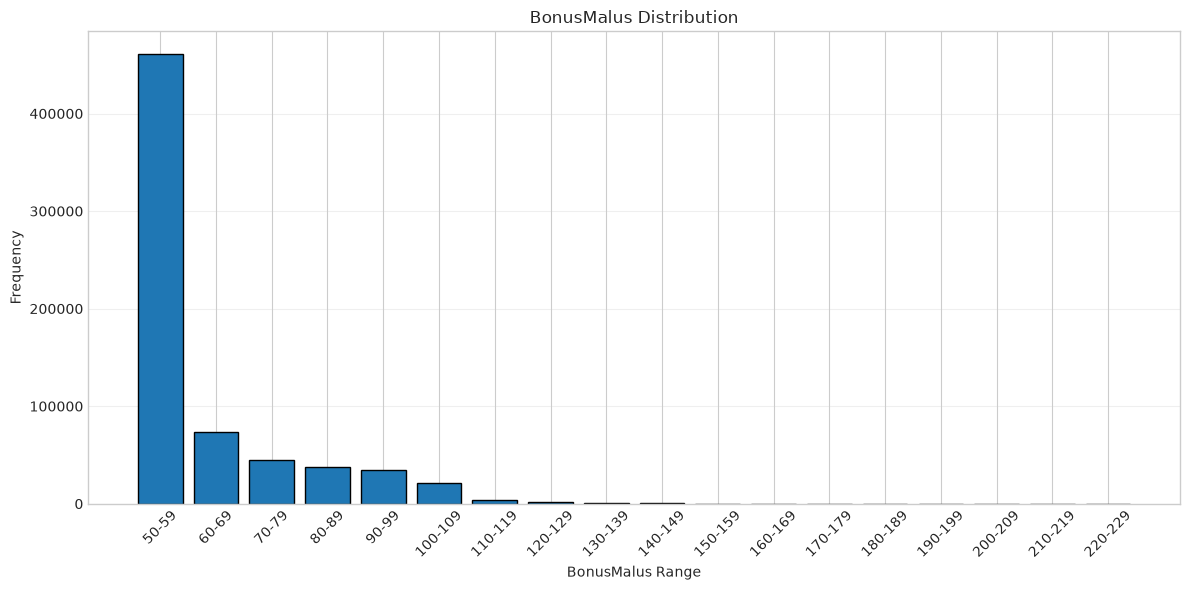

In [51]:
plt.figure(figsize=(12, 6))

plt.bar(bm_bins.keys(), bm_bins.values(), edgecolor='black')

plt.xlabel('BonusMalus Range')
plt.ylabel('Frequency')
plt.title('BonusMalus Distribution')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()